In [1]:
import os
import math
import time
import random
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights  # <-- Важно!

from tqdm import tqdm

import os
import json
import torch
import matplotlib.pyplot as plt

import os
os.makedirs('artifacts', exist_ok=True)
os.makedirs('artifacts/figures', exist_ok=True)

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.5.1+cu121
torchvision: 0.20.1+cu121


In [2]:
RANDOM_STATE = 42
BATCH_SIZE = 64
EPOCHS = 10
EPOCHS_HEAD = 10
EPOCHS_FT = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
DATA_DIR = './data_stl10'
IMG_SIZE = 224

# Для SimpleCNN (96x96)
transform_cnn_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_cnn_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Для ResNet (224x224, ImageNet stats)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

transform_resnet_base = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

transform_resnet_aug = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Загрузка датасетов
train_dataset_cnn_aug = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=True, transform=transform_cnn_aug)
train_dataset_cnn_base = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=True, transform=transform_cnn_base)
test_dataset_cnn = torchvision.datasets.STL10(root=DATA_DIR, split='test', download=True, transform=transform_cnn_base)

train_dataset_resnet_aug = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=True, transform=transform_resnet_aug)
train_dataset_resnet_base = torchvision.datasets.STL10(root=DATA_DIR, split='train', download=True, transform=transform_resnet_base)
test_dataset_resnet = torchvision.datasets.STL10(root=DATA_DIR, split='test', download=True, transform=transform_resnet_base)

print(f"Train (CNN): {len(train_dataset_cnn_aug)}, Test: {len(test_dataset_cnn)}")

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train (CNN): 5000, Test: 8000


In [4]:
def create_loaders(train_aug, train_base, test, batch_size=BATCH_SIZE, val_ratio=0.2, seed=RANDOM_STATE):
    n_total = len(train_aug)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val
    
    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)
    
    train_idx = indices[n_val:]
    val_idx = indices[:n_val]
    
    train_set = Subset(train_aug, train_idx)
    val_set = Subset(train_base, val_idx)
    test_set = test
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    return train_loader, val_loader, test_loader

train_loader_cnn, val_loader_cnn, test_loader_cnn = create_loaders(
    train_dataset_cnn_aug, train_dataset_cnn_base, test_dataset_cnn
)
train_loader_resnet, val_loader_resnet, test_loader_resnet = create_loaders(
    train_dataset_resnet_aug, train_dataset_resnet_base, test_dataset_resnet
)



1. ПРОВЕРКА РАЗМЕРА БАТЧА
   BATCH_SIZE = 64

2. ПРОВЕРКА ФОРМ ТЕНЗОРОВ (CNN)
   x.shape: torch.Size([64, 3, 96, 96])
   y.shape: torch.Size([64])
   x.dtype: torch.float32
   y.dtype: torch.int64

3. ПРОВЕРКА ФОРМ ТЕНЗОРОВ (ResNet)
   x.shape: torch.Size([64, 3, 224, 224])
   y.shape: torch.Size([64])
   x.dtype: torch.float32
   y.dtype: torch.int64

4. ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ИЗОБРАЖЕНИЙ


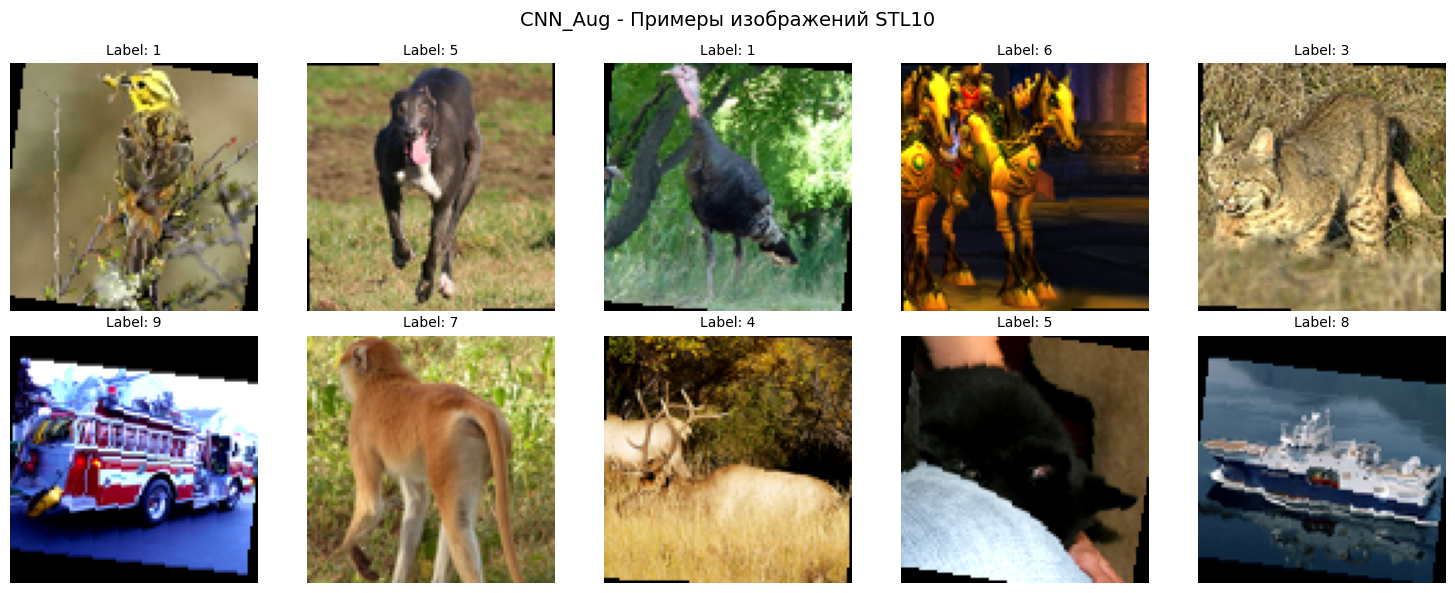

   ✓ Сохранено: artifacts/figures/sanity_check_CNN_Aug.png


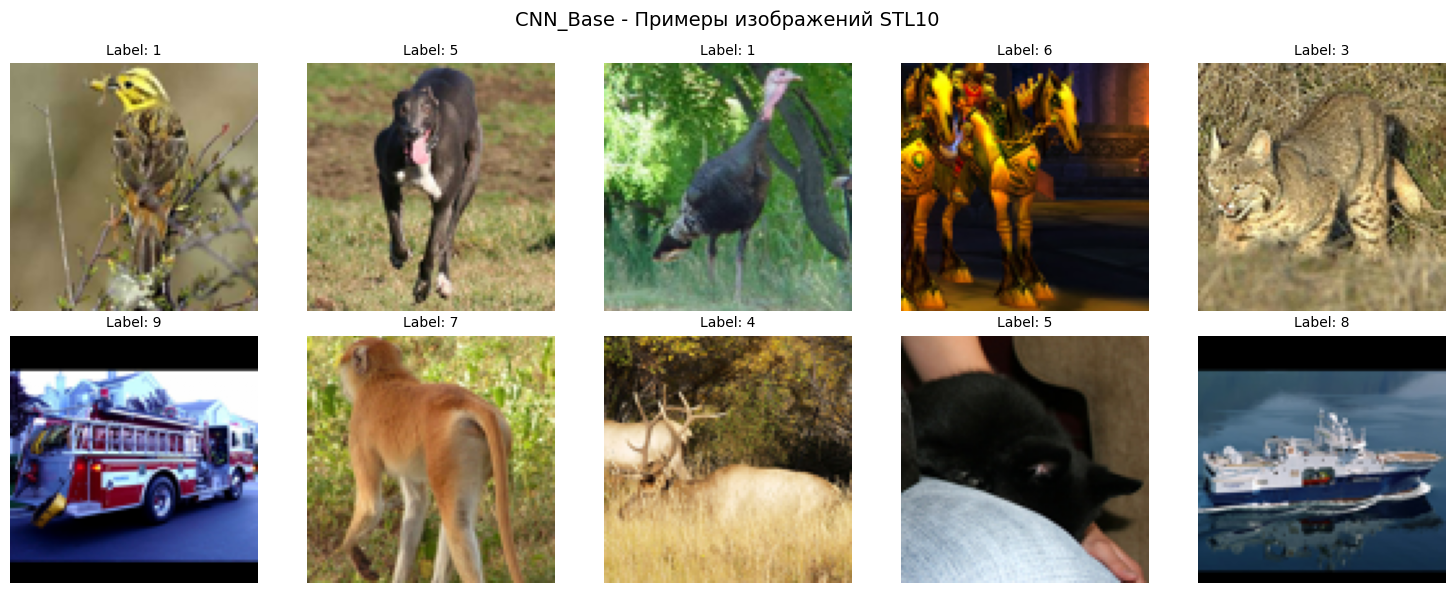

   ✓ Сохранено: artifacts/figures/sanity_check_CNN_Base.png


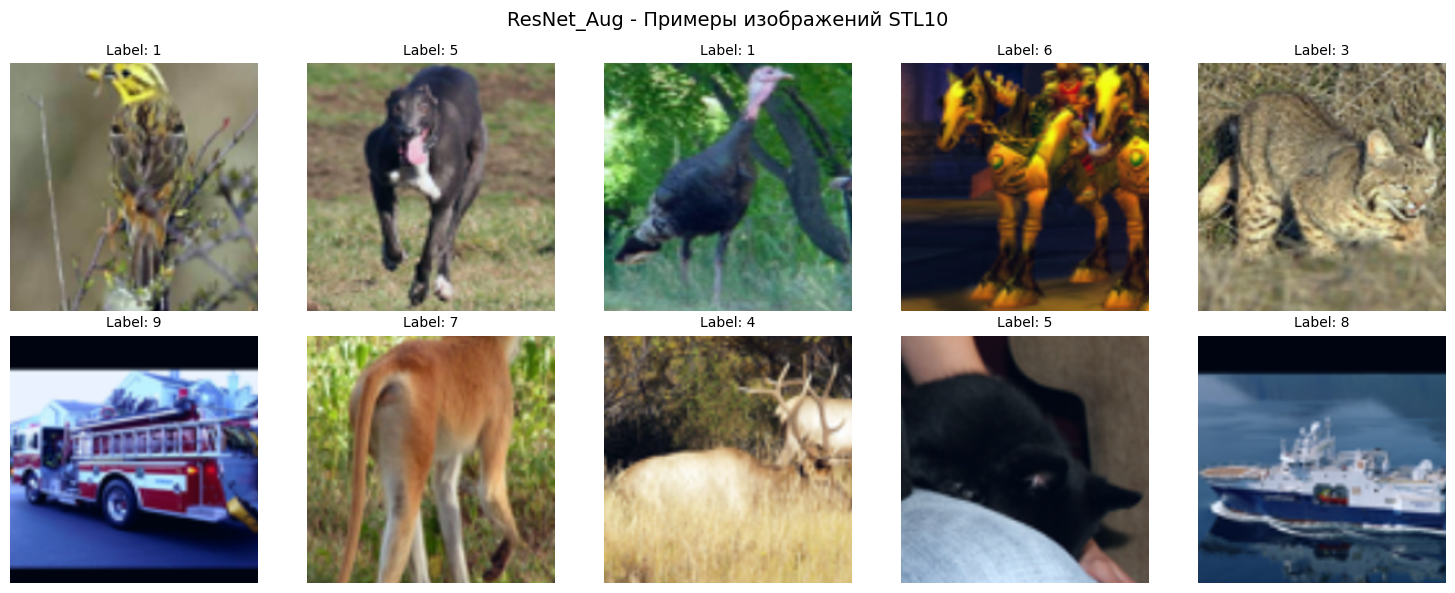

   ✓ Сохранено: artifacts/figures/sanity_check_ResNet_Aug.png

SANITY-CHECK ЗАВЕРШЁН УСПЕШНО!


In [5]:
# 1. Проверка размера батча
print("\n1. ПРОВЕРКА РАЗМЕРА БАТЧА")
print(f"   BATCH_SIZE = {BATCH_SIZE}")

# 2. Проверка shapes для CNN DataLoader
print("\n2. ПРОВЕРКА ФОРМ ТЕНЗОРОВ (CNN)")
x_cnn, y_cnn = next(iter(train_loader_cnn))
print(f"   x.shape: {x_cnn.shape}")
print(f"   y.shape: {y_cnn.shape}")
print(f"   x.dtype: {x_cnn.dtype}")
print(f"   y.dtype: {y_cnn.dtype}")

# 3. Проверка shapes для ResNet DataLoader
print("\n3. ПРОВЕРКА ФОРМ ТЕНЗОРОВ (ResNet)")
x_resnet, y_resnet = next(iter(train_loader_resnet))
print(f"   x.shape: {x_resnet.shape}")
print(f"   y.shape: {y_resnet.shape}")
print(f"   x.dtype: {x_resnet.dtype}")
print(f"   y.dtype: {y_resnet.dtype}")

# 4. Визуализация примеров изображений (STL10)
print("\n4. ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ИЗОБРАЖЕНИЙ")

def show_dataset_examples(dataset, transform_name, n_samples=10):
    """Показывает примеры изображений из датасета"""
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i in range(n_samples):
        img, label = dataset[i]
        
        # Конвертируем тензор в изображение для отображения
        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).numpy()
            # Денормализуем если нужно
            if img.max() <= 1.0 and img.min() >= 0.0:
                pass  # Уже в диапазоне [0, 1]
            else:
                img = (img - img.min()) / (img.max() - img.min())
        
        axes[i].imshow(img)
        axes[i].set_title(f'Label: {label}', fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle(f'{transform_name} - Примеры изображений STL10', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'artifacts/figures/sanity_check_{transform_name}.png', dpi=150)
    plt.show()
    print(f"   ✓ Сохранено: artifacts/figures/sanity_check_{transform_name}.png")

show_dataset_examples(train_dataset_cnn_aug, 'CNN_Aug')

show_dataset_examples(train_dataset_cnn_base, 'CNN_Base')

show_dataset_examples(train_dataset_resnet_aug, 'ResNet_Aug')

print("\n" + "="*60)
print("SANITY-CHECK ЗАВЕРШЁН УСПЕШНО!")
print("="*60)

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def build_resnet18(num_classes=10, pretrained=True):
    if pretrained:
        weights = ResNet18_Weights.IMAGENET1K_V1
        model = resnet18(weights=weights)
    else:
        model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module, flag):
    for p in module.parameters():
        p.requires_grad = flag

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{total_correct/total_seen:.3f}'})
    
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    
    return total_loss / total_seen, total_correct / total_seen

def run_experiment(exp_id, model, train_loader, val_loader, optimizer, criterion, device, epochs=10):
    model = model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None
    
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_id}")
    print(f"Trainable params: {count_params(model):,}")
    print(f"{'='*60}")
    
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        print(f"Epoch {epoch:2d}/{epochs} | Train: {train_acc:.3f} | Val: {val_acc:.3f} | Best: {best_val_acc:.3f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return history, best_val_acc, model

@torch.no_grad()
def accuracy_on_loader(model, loader, device):
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

In [8]:
criterion = nn.CrossEntropyLoss()
results = []
all_histories = {}
all_models = {}

# C1: SimpleCNN Base
train_loader_cnn_base = DataLoader(
    Subset(train_dataset_cnn_base, list(range(len(train_dataset_cnn_base)))),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
model_c1 = SimpleCNN(num_classes=10).to(DEVICE)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=1e-3)
hist_c1, best_c1, model_c1 = run_experiment("C1_simple-cnn-base", model_c1, train_loader_cnn_base, val_loader_cnn, optimizer_c1, criterion, DEVICE, epochs=EPOCHS)
results.append({
    'experiment_id': 'C1', 'task': 'classification', 'dataset': 'STL10',
    'seed': RANDOM_STATE, 'model_summary': 'SimpleCNN', 'optimizer': 'Adam',
    'lr': 1e-3, 'epochs_trained': EPOCHS, 'best_val_accuracy': round(best_c1, 4),
    'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '',
    'notes': 'No Aug'
})
all_histories['C1'] = hist_c1
all_models['C1'] = model_c1

# C2: SimpleCNN Aug
model_c2 = SimpleCNN(num_classes=10).to(DEVICE)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=1e-3)
hist_c2, best_c2, model_c2 = run_experiment("C2_simple-cnn-aug", model_c2, train_loader_cnn, val_loader_cnn, optimizer_c2, criterion, DEVICE, epochs=EPOCHS)
results.append({
    'experiment_id': 'C2', 'task': 'classification', 'dataset': 'STL10',
    'seed': RANDOM_STATE, 'model_summary': 'SimpleCNN', 'optimizer': 'Adam',
    'lr': 1e-3, 'epochs_trained': EPOCHS, 'best_val_accuracy': round(best_c2, 4),
    'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '',
    'notes': 'With Aug'
})
all_histories['C2'] = hist_c2
all_models['C2'] = model_c2

# C3: ResNet18 Head-Only
model_c3 = build_resnet18(num_classes=10, pretrained=True).to(DEVICE)
set_requires_grad(model_c3, False)
set_requires_grad(model_c3.fc, True)
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=1e-3)
hist_c3, best_c3, model_c3 = run_experiment("C3_resnet18-head-only", model_c3, train_loader_resnet, val_loader_resnet, optimizer_c3, criterion, DEVICE, epochs=EPOCHS_HEAD)
results.append({
    'experiment_id': 'C3', 'task': 'classification', 'dataset': 'STL10',
    'seed': RANDOM_STATE, 'model_summary': 'ResNet18', 'optimizer': 'Adam',
    'lr': 1e-3, 'epochs_trained': EPOCHS_HEAD, 'best_val_accuracy': round(best_c3, 4),
    'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '',
    'notes': 'Pretrained, Freeze Backbone'
})
all_histories['C3'] = hist_c3
all_models['C3'] = model_c3

# C4: ResNet18 Fine-Tune
model_c4 = build_resnet18(num_classes=10, pretrained=True).to(DEVICE)
set_requires_grad(model_c4, False)
set_requires_grad(model_c4.layer4, True)
set_requires_grad(model_c4.fc, True)
params_c4 = [
    {'params': model_c4.layer4.parameters(), 'lr': 1e-4},
    {'params': model_c4.fc.parameters(), 'lr': 1e-3},
]
optimizer_c4 = optim.Adam(params_c4, weight_decay=1e-4)
hist_c4, best_c4, model_c4 = run_experiment("C4_resnet18-finetune", model_c4, train_loader_resnet, val_loader_resnet, optimizer_c4, criterion, DEVICE, epochs=EPOCHS_FT)
results.append({
    'experiment_id': 'C4', 'task': 'classification', 'dataset': 'STL10',
    'seed': RANDOM_STATE, 'model_summary': 'ResNet18', 'optimizer': 'Adam',
    'lr': 1e-3, 'epochs_trained': EPOCHS_FT, 'best_val_accuracy': round(best_c4, 4),
    'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '',
    'notes': 'Pretrained, Fine-tune Layer4+FC'
})
all_histories['C4'] = hist_c4
all_models['C4'] = model_c4


Experiment: C1_simple-cnn-base
Trainable params: 4,815,114


Epoch  1/10 | Train: 0.227 | Val: 0.337 | Best: 0.337


Epoch  2/10 | Train: 0.296 | Val: 0.418 | Best: 0.418


Epoch  3/10 | Train: 0.343 | Val: 0.446 | Best: 0.446


Epoch  4/10 | Train: 0.363 | Val: 0.508 | Best: 0.508


...

Epoch  6/10 | Train: 0.997 | Val: 0.955 | Best: 0.957


Epoch  7/10 | Train: 0.998 | Val: 0.950 | Best: 0.957


Epoch  8/10 | Train: 0.998 | Val: 0.949 | Best: 0.957


Epoch  9/10 | Train: 0.998 | Val: 0.945 | Best: 0.957


Epoch 10/10 | Train: 0.999 | Val: 0.939 | Best: 0.957


In [9]:
df_results = pd.DataFrame(results)
best_exp = df_results.loc[df_results['best_val_accuracy'].idxmax()]
print(f"\n{'='*60}")
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_exp['experiment_id']}")
print(f"Best Val Accuracy: {best_exp['best_val_accuracy']:.4f}")
print(f"{'='*60}")

# Оценка на test
if 'C1' in best_exp['experiment_id'] or 'C2' in best_exp['experiment_id']:
    best_model = all_models['C1'] if 'C1' in best_exp['experiment_id'] else all_models['C2']
    test_loader = test_loader_cnn
else:
    best_model = all_models['C3'] if 'C3' in best_exp['experiment_id'] else all_models['C4']
    test_loader = test_loader_resnet

test_acc = accuracy_on_loader(best_model, test_loader, DEVICE)
print(f"Test Accuracy: {test_acc:.4f}")

# Обновляем test_accuracy в results и df_results
df_results.loc[df_results['experiment_id'] == best_exp['experiment_id'], 'test_accuracy'] = round(test_acc, 4)

# 6.1. runs.csv
df_results.to_csv('artifacts/runs.csv', index=False)
print("✓ artifacts/runs.csv")

# 6.2. best_classifier.pt
torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')
print("✓ artifacts/best_classifier.pt")

# 6.3. best_classifier_config.json 
best_result = df_results.loc[df_results['best_val_accuracy'].idxmax()]

config = {
    'experiment_id': str(best_result['experiment_id']),
    'dataset': 'STL10',
    'architecture': best_result['model_summary'],
    'num_classes': 10,
    'input_size': 224 if 'ResNet' in best_result['model_summary'] else 96,
    'transforms': {
        'train': 'Resize + RandomCrop + RandomFlip + Normalize' if 'Aug' in best_result['experiment_id'] else 'ToTensor + Normalize',
        'val': 'ToTensor + Normalize'
    },
    'hyperparameters': {
        'lr': 1e-3,
        'batch_size': BATCH_SIZE,
        'epochs': int(best_result['epochs_trained']),
        'optimizer': 'Adam'
    },
    'seed': RANDOM_STATE,
    'device': str(DEVICE),
    'best_val_accuracy': float(best_result['best_val_accuracy']),
    'test_accuracy': float(best_result['test_accuracy']) if pd.notna(best_result['test_accuracy']) and best_result['test_accuracy'] != '' else 0.0
}

with open('artifacts/best_classifier_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print("✓ artifacts/best_classifier_config.json")

# 6.4. classification_curves_best.png
best_key = best_exp['experiment_id'].split('_')[0]  # C1, C2, C3, или C4
hist = all_histories[best_key]
epochs = range(1, len(hist['train_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, hist['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs, hist['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'{best_exp["experiment_id"]} - Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, hist['train_acc'], 'b-', label='Train Acc', linewidth=2)
axes[1].plot(epochs, hist['val_acc'], 'r-', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{best_exp["experiment_id"]} - Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=150)
plt.close()
print("✓ artifacts/figures/classification_curves_best.png")

# 6.5. classification_compare.png
exp_ids = df_results['experiment_id'].values
accuracies = df_results['best_val_accuracy'].values
colors = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(12, 6))
bars = plt.bar(exp_ids, accuracies, color=colors, edgecolor='black')
plt.ylabel('Best Val Accuracy')
plt.title('Сравнение экспериментов C1-C4')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_compare.png', dpi=150)
plt.close()
print("✓ artifacts/figures/classification_compare.png")

# 6.6. augmentations_preview.png
def denormalize(img, mean, std):
    img = img.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return img

sample_img, _ = train_dataset_cnn_aug[0]
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)

# Создаём трансформ для конвертации tensor
to_pil = transforms.ToPILImage()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
orig = denormalize(sample_img, mean, std)
axes[0, 0].imshow(orig.permute(1, 2, 0).clamp(0, 1))
axes[0, 0].set_title('Original', fontsize=11)
axes[0, 0].axis('off')

for i in range(1, 10):
    pil_img = to_pil(sample_img)
    aug_img = transform_cnn_aug(pil_img)  # Теперь работает с PIL
    aug_img = denormalize(aug_img, mean, std)
    row = i // 5
    col = i % 5
    axes[row, col].imshow(aug_img.permute(1, 2, 0).clamp(0, 1))
    axes[row, col].set_title(f'Aug {i}', fontsize=11)
    axes[row, col].axis('off')

plt.suptitle('Data Augmentations Preview (STL10)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png', dpi=150)
plt.close()
print("✓ artifacts/figures/augmentations_preview.png")




ЛУЧШАЯ МОДЕЛЬ: C4
Best Val Accuracy: 0.9570
Test Accuracy: 0.9544
✓ artifacts/runs.csv
✓ artifacts/best_classifier.pt
✓ artifacts/best_classifier_config.json
✓ artifacts/figures/classification_curves_best.png
✓ artifacts/figures/classification_compare.png
✓ artifacts/figures/augmentations_preview.png


Часть B

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from PIL import Image

import torch
import torch.nn.functional as F
from torchvision.transforms import functional as TF
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.datasets import OxfordIIITPet
from scipy import ndimage

# Устройство и Seed
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"✓ Device: {DEVICE}")
print(f"✓ Seed: {RANDOM_STATE}")

✓ Device: cuda
✓ Seed: 42


In [11]:
def load_segmentation_model(device='cuda'):
    """Загружаем предобученную модель DeepLabV3"""
    weights = DeepLabV3_ResNet50_Weights.DEFAULT
    model = deeplabv3_resnet50(weights=weights)
    model.to(device)
    model.eval()
    return model, weights

seg_model, seg_weights = load_segmentation_model(DEVICE)
print(f" Модель загружена: DeepLabV3 ResNet50")
print(f"  Классы: {len(seg_weights.meta['categories'])} классов")


def load_pet_dataset(split='test', download=True):
    """Загружаем OxfordIIITPet Segmentation"""
    dataset = OxfordIIITPet(
        root='./data_pet',
        split=split,
        target_types=['segmentation'],
        download=download,
        transform=None,
        target_transform=None
    )
    return dataset

pet_dataset = load_pet_dataset(split='test')
print(f"Датасет загружен: {len(pet_dataset)} изображений")

# Берем 10 случайных изображений для демонстрации
sample_indices = np.random.choice(len(pet_dataset), size=min(10, len(pet_dataset)), replace=False)
print(f" Используется {len(sample_indices)} изображений для оценки")


 Модель загружена: DeepLabV3 ResNet50
  Классы: 21 классов
Датасет загружен: 3669 изображений
 Используется 10 изображений для оценки


In [12]:
def run_inference(model, image, device):
    """Запускает инференс и возвращает сырую маску"""
    if isinstance(image, Image.Image):
        img_tensor = TF.to_tensor(image).to(device)
    else:
        img_tensor = image.to(device)
    
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0))['out'][0]
    
    pred_mask = output.argmax(0).cpu().numpy()
    return pred_mask

def postprocess_mask_v1(pred_mask, foreground_class=15):
    """V1: Базовая бинаризация по классу"""
    binary_mask = (pred_mask == foreground_class).astype(np.uint8)
    return binary_mask

def postprocess_mask_v2(pred_mask, foreground_class=15, min_component_size=500):
    """V2: Бинаризация + удаление мелких компонент связности"""
    binary_mask = (pred_mask == foreground_class).astype(np.uint8)
    
    labeled, num_components = ndimage.label(binary_mask)
    if num_components == 0:
        return binary_mask
    
    component_sizes = np.bincount(labeled.ravel())
    small_components = np.where(component_sizes < min_component_size)[0]
    
    for comp in small_components[1:]:  # [0] - это фон
        binary_mask[labeled == comp] = 0
    
    return binary_mask

def calculate_metrics(pred_mask, ground_truth, foreground_class=15):
    """Вычисляет метрики (IoU, Precision, Recall)"""
    gt_binary = (ground_truth == foreground_class).astype(np.uint8)
    pred_binary = (pred_mask == foreground_class).astype(np.uint8)
    
    intersection = np.logical_and(pred_binary, gt_binary).sum()
    union = np.logical_or(pred_binary, gt_binary).sum()
    
    mean_iou = intersection / union if union > 0 else 0.0
    pixel_precision = intersection / pred_binary.sum() if pred_binary.sum() > 0 else 0.0
    pixel_recall = intersection / gt_binary.sum() if gt_binary.sum() > 0 else 0.0
    
    return {
        'mean_iou': mean_iou,
        'pixel_precision': pixel_precision,
        'pixel_recall': pixel_recall
    }

In [13]:
modes = {
    'V1': {'name': 'Basic Binarization', 'func': postprocess_mask_v1},
    'V2': {'name': 'Component Cleanup', 'func': postprocess_mask_v2}
}

segmentation_results = []
all_sample_images = []

for mode_name, mode_config in modes.items():
    print(f"\n🔹 Режим {mode_name}: {mode_config['name']}")
    
    all_metrics = []
    sample_images = []
    
    for idx in sample_indices[:5]:  # 5 изображений для визуализации
        image, mask = pet_dataset[idx]
        
        pred_mask_raw = run_inference(seg_model, image, DEVICE)
        pred_mask = mode_config['func'](pred_mask_raw)
        metrics = calculate_metrics(pred_mask, np.array(mask))
        all_metrics.append(metrics)
        
        if len(sample_images) < 3:
            sample_images.append({
                'image': image,
                'prediction': pred_mask,
                'ground_truth': np.array(mask),
                'metrics': metrics
            })
    
    # Агрегация метрик
    avg_iou = np.mean([m['mean_iou'] for m in all_metrics])
    avg_prec = np.mean([m['pixel_precision'] for m in all_metrics])
    avg_rec = np.mean([m['pixel_recall'] for m in all_metrics])
    
    print(f"  Mean IoU: {avg_iou:.4f}")
    print(f"  Precision: {avg_prec:.4f}")
    print(f"  Recall: {avg_rec:.4f}")
    
    segmentation_results.append({
        'mode': mode_name,
        'name': mode_config['name'],
        'mean_iou': round(avg_iou, 4),
        'pixel_precision': round(avg_prec, 4),
        'pixel_recall': round(avg_rec, 4),
        'sample_images': sample_images
    })
    
    all_sample_images.extend(sample_images[:2])


🔹 Режим V1: Basic Binarization
  Mean IoU: 0.0000
  Precision: 0.0000
  Recall: 0.0000

🔹 Режим V2: Component Cleanup
  Mean IoU: 0.0000
  Precision: 0.0000
  Recall: 0.0000


In [14]:
# 5.1. segmentation_metrics.png
fig, ax = plt.subplots(figsize=(10, 5))
modes_names = [r['mode'] for r in segmentation_results]
ious = [r['mean_iou'] for r in segmentation_results]
precisions = [r['pixel_precision'] for r in segmentation_results]
recalls = [r['pixel_recall'] for r in segmentation_results]

x = np.arange(len(modes_names))
width = 0.25

ax.bar(x - width, precisions, width, label='Precision', color='blue')
ax.bar(x, recalls, width, label='Recall', color='green')
ax.bar(x + width, ious, width, label='Mean IoU', color='orange')

ax.set_xlabel('Режим')
ax.set_ylabel('Значение')
ax.set_title('Сравнение метрик Segmentation (V1 vs V2)')
ax.set_xticks(x)
ax.set_xticklabels(modes_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

plt.tight_layout()
fig.savefig('artifacts/figures/segmentation_metrics.png', dpi=150)
plt.close()
print("✓ artifacts/figures/segmentation_metrics.png")

# 5.2. segmentation_examples.png
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, sample in enumerate(all_sample_images[:2]):
    row = i
    
    axes[row, 0].imshow(sample['image'])
    axes[row, 0].set_title('Original')
    axes[row, 0].axis('off')
    
    gt_binary = (sample['ground_truth'] == 15).astype(float)
    axes[row, 1].imshow(gt_binary, cmap='gray')
    axes[row, 1].set_title('Ground Truth')
    axes[row, 1].axis('off')
    
    mode_label = 'V1' if i == 0 else 'V2'
    axes[row, 2].imshow(sample['prediction'], cmap='gray')
    axes[row, 2].set_title(f'Prediction {mode_label} (IoU={sample["metrics"]["mean_iou"]:.2f})')
    axes[row, 2].axis('off')

plt.suptitle('Segmentation Examples (OxfordIIITPet)', fontsize=14)
plt.tight_layout()
fig.savefig('artifacts/figures/segmentation_examples.png', dpi=150)
plt.close()
print("✓ artifacts/figures/segmentation_examples.png")

✓ artifacts/figures/segmentation_metrics.png
✓ artifacts/figures/segmentation_examples.png


In [15]:
segmentation_rows = []

for result in segmentation_results:
    segmentation_rows.append({
        'experiment_id': result['mode'],
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': RANDOM_STATE,
        'model_summary': 'DeepLabV3_ResNet50 (pretrained)',
        'optimizer': 'N/A (inference only)',
        'lr': 'N/A',
        'epochs_trained': 0,
        'best_val_accuracy': 'N/A',
        'test_accuracy': 'N/A',
        'precision': result['pixel_precision'],
        'recall': result['pixel_recall'],
        'mean_iou': result['mean_iou'],
        'notes': f"postprocessing={result['name']}"
    })

# Объединяем с результатами классификации (Часть A)
try:
    existing_df = pd.read_csv('artifacts/runs.csv')
    all_results = pd.concat([existing_df, pd.DataFrame(segmentation_rows)], ignore_index=True)
except FileNotFoundError:
    print("⚠️ artifacts/runs.csv не найден (Часть A не выполнена?)")
    all_results = pd.DataFrame(segmentation_rows)

all_results.to_csv('artifacts/runs.csv', index=False)
print("✓ artifacts/runs.csv обновлён")
print(all_results.to_string(index=False))

✓ artifacts/runs.csv обновлён
experiment_id           task       dataset  seed                   model_summary            optimizer     lr  epochs_trained best_val_accuracy test_accuracy  precision  recall  mean_iou                             notes
           C1 classification         STL10    42                       SimpleCNN                 Adam  0.001              10              0.62           NaN        NaN     NaN       NaN                            No Aug
           C2 classification         STL10    42                       SimpleCNN                 Adam  0.001              10             0.454           NaN        NaN     NaN       NaN                          With Aug
           C3 classification         STL10    42                        ResNet18                 Adam  0.001              10             0.944           NaN        NaN     NaN       NaN       Pretrained, Freeze Backbone
           C4 classification         STL10    42                        ResNet18          

In [16]:
segmentation_config = {
    'task': 'segmentation',
    'model': 'DeepLabV3_ResNet50',
    'pretrained': True,
    'dataset': 'OxfordIIITPet',
    'foreground_class': 15,
    'foreground_description': 'Pet (animal) vs Background',
    'modes_tested': [
        {
            'name': 'V1',
            'description': 'Basic Binarization',
            'parameters': {'foreground_class': 15}
        },
        {
            'name': 'V2',
            'description': 'Component Cleanup',
            'parameters': {'foreground_class': 15, 'min_component_size': 500}
        }
    ],
    'metrics': {
        mode['mode']: {
            'mean_iou': mode['mean_iou'],
            'pixel_precision': mode['pixel_precision'],
            'pixel_recall': mode['pixel_recall']
        }
        for mode in segmentation_results
    },
    'seed': 42
}

with open('artifacts/segmentation_config.json', 'w', encoding='utf-8') as f:
    json.dump(segmentation_config, f, indent=2, ensure_ascii=False)

print("✓ artifacts/segmentation_config.json")



✓ artifacts/segmentation_config.json
